# **Lecture 27: Mathematical Foundations of the Lax-Friedrichs Scheme**

**Course:** Computational Astrophysics (PHYS 8202)

**Topic:** Numerical Viscosity, Taylor Expansions, and Modified Equation Analysis

***

## **1. The Naive Approach: Forward Time, Centered Space (FTCS)**

In the previous lecture, we established the 1D Advection Equation for fluid density $\rho$ moving at a constant velocity $v$:
$$\frac{\partial \rho}{\partial t} + v \frac{\partial \rho}{\partial x} = 0$$

The most intuitive way to discretize this on a grid is to use a Forward Euler step in time and a Central Difference step in space. This is known as the FTCS scheme:
$$\frac{\rho_i^{n+1} - \rho_i^n}{\Delta t} + v \frac{\rho_{i+1}^n - \rho_{i-1}^n}{2\Delta x} = 0$$

Solving for the future state $\rho_i^{n+1}$ yields:
$$\rho_i^{n+1} = \rho_i^n - \frac{v \Delta t}{2\Delta x}(\rho_{i+1}^n - \rho_{i-1}^n)$$

While this looks mathematically sound, **FTCS is unconditionally unstable for the advection equation**. If you code this, any tiny floating-point error will grow exponentially, and the simulation will blow up within a few time steps. Von Neumann stability analysis proves that the amplification factor for FTCS is always greater than 1.

## **2. The Lax-Friedrichs Modification**

In 1954, Peter Lax recognized a brilliant algebraic trick to stabilize the FTCS scheme. He proposed replacing the current state $\rho_i^n$ with the spatial average of its immediate neighbors:
$$\rho_i^n \rightarrow \frac{1}{2}(\rho_{i+1}^n + \rho_{i-1}^n)$$

Substituting this into the FTCS equation gives the **Lax-Friedrichs Scheme**:
$$\rho_i^{n+1} = \frac{1}{2}(\rho_{i+1}^n + \rho_{i-1}^n) - \frac{v \Delta t}{2\Delta x}(\rho_{i+1}^n - \rho_{i-1}^n)$$

Why does this simple substitution magically make the scheme stable? To understand the physics of what we just did, we must perform a Modified Equation Analysis.

## **3. Modified Equation Analysis (The Math of Numerical Viscosity)**

We want to know what continuous partial differential equation our discrete Lax-Friedrichs scheme is *actually* solving. We do this by expanding the discrete terms using Taylor series around the point $(x_i, t^n)$.

The Taylor expansions are:
$$\rho_i^{n+1} = \rho + \Delta t \frac{\partial \rho}{\partial t} + \frac{\Delta t^2}{2} \frac{\partial^2 \rho}{\partial t^2} + O(\Delta t^3)$$
$$\rho_{i+1}^n = \rho + \Delta x \frac{\partial \rho}{\partial x} + \frac{\Delta x^2}{2} \frac{\partial^2 \rho}{\partial x^2} + O(\Delta x^3)$$
$$\rho_{i-1}^n = \rho - \Delta x \frac{\partial \rho}{\partial x} + \frac{\Delta x^2}{2} \frac{\partial^2 \rho}{\partial x^2} + O(\Delta x^3)$$

Now, we substitute these expansions back into the rearranged Lax-Friedrichs scheme:
$$\frac{\rho_i^{n+1} - \frac{1}{2}(\rho_{i+1}^n + \rho_{i-1}^n)}{\Delta t} + v \frac{\rho_{i+1}^n - \rho_{i-1}^n}{2\Delta x} = 0$$

**Step A: The Time Derivative Term**
$$\frac{\rho_i^{n+1} - \frac{1}{2}(\rho_{i+1}^n + \rho_{i-1}^n)}{\Delta t} = \frac{\partial \rho}{\partial t} + \frac{\Delta t}{2} \frac{\partial^2 \rho}{\partial t^2} - \frac{\Delta x^2}{2\Delta t} \frac{\partial^2 \rho}{\partial x^2} + \dots$$

**Step B: The Space Derivative Term**
$$v \frac{\rho_{i+1}^n - \rho_{i-1}^n}{2\Delta x} = v \frac{\partial \rho}{\partial x} + \dots$$

**Step C: Combine and Simplify**
Bringing it all together and keeping only the leading error terms, we get:
$$\frac{\partial \rho}{\partial t} + v \frac{\partial \rho}{\partial x} = \frac{\Delta x^2}{2\Delta t} \frac{\partial^2 \rho}{\partial x^2} - \frac{\Delta t}{2} \frac{\partial^2 \rho}{\partial t^2}$$

Using the original PDE ($\frac{\partial \rho}{\partial t} = -v \frac{\partial \rho}{\partial x}$), we can replace the second time derivative:
$$\frac{\partial^2 \rho}{\partial t^2} = v^2 \frac{\partial^2 \rho}{\partial x^2}$$

This leaves us with the final **Modified Equation**:
$$\frac{\partial \rho}{\partial t} + v \frac{\partial \rho}{\partial x} = \left( \frac{\Delta x^2}{2\Delta t} - \frac{v^2 \Delta t}{2} \right) \frac{\partial^2 \rho}{\partial x^2}$$


### **The Physical Interpretation**
Look closely at the right-hand side of that final equation. It is no longer zero! 

By substituting the spatial average, we inadvertently introduced a second-order spatial derivative. In physics, an equation of the form $\frac{\partial \rho}{\partial t} = \alpha \frac{\partial^2 \rho}{\partial x^2}$ is the **Diffusion Equation** (or Heat Equation).

Therefore, the Lax-Friedrichs scheme does not solve the pure advection equation. It actually solves an advection-diffusion equation. The artificial diffusion coefficient is:
$$\alpha_{num} = \frac{\Delta x^2}{2\Delta t} - \frac{v^2 \Delta t}{2}$$

This **Numerical Viscosity** acts to smooth out sharp gradients. It completely cures the instability of the FTCS scheme, but it comes at the cost of smearing out our astrophysical shockwaves. Let us visualize this smearing effect using a square wave (representing a sudden supernova shock front).

Calculated Numerical Viscosity (alpha): 0.1319


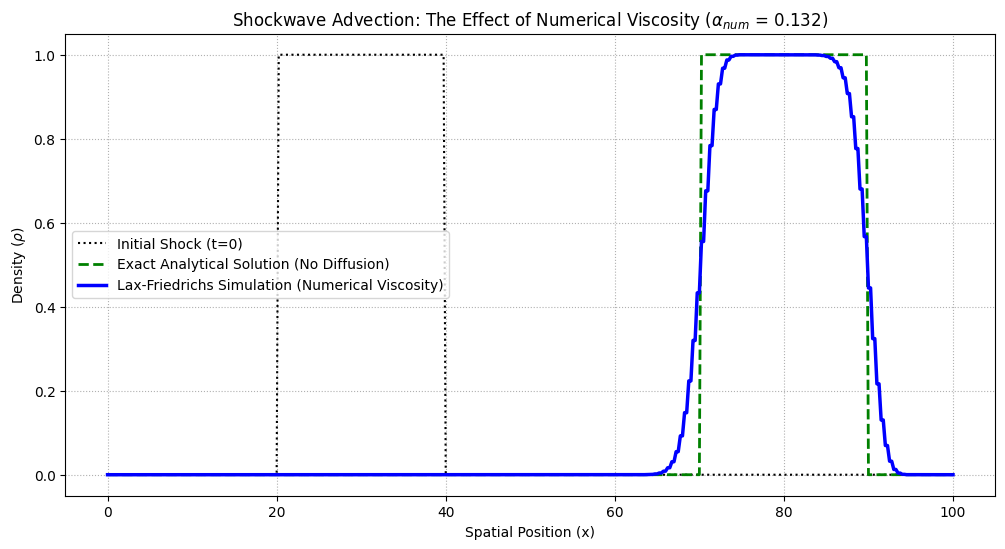

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the Spatial Grid
L = 100.0
nx = 401
dx = L / (nx - 1)
x = np.linspace(0, L, nx)

# 2. Physical Parameters
v = 5.0
C = 0.9           # Courant Number (Must be <= 1.0 for stability)
dt = C * dx / v
t_final = 10.0
nt = int(t_final / dt)

# 3. Initial Condition (A sharp Square Wave Shock Front)
rho_initial = np.zeros(nx)
rho_initial[(x > 20) & (x < 40)] = 1.0
rho = rho_initial.copy()
rho_next = np.zeros(nx)

# Calculate the theoretical numerical viscosity
alpha_num = (dx**2 / (2 * dt)) - (v**2 * dt / 2)
print(f"Calculated Numerical Viscosity (alpha): {alpha_num:.4f}")

# 4. Lax-Friedrichs Integration
for n in range(nt):
    for i in range(1, nx - 1):
        rho_next[i] = 0.5 * (rho[i+1] + rho[i-1]) - (v * dt / (2.0 * dx)) * (rho[i+1] - rho[i-1])
    
    # Periodic Boundaries
    rho_next[0] = 0.5 * (rho[1] + rho[-2]) - (v * dt / (2.0 * dx)) * (rho[1] - rho[-2])
    rho_next[-1] = rho_next[0]
    
    rho[:] = rho_next[:]

# 5. Exact Analytical Solution (Perfect Advection without diffusion)
# The wave should just shift by distance = v * t_final
shift_distance = v * t_final
rho_exact = np.zeros(nx)
rho_exact[(x > 20 + shift_distance) & (x < 40 + shift_distance)] = 1.0

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(x, rho_initial, 'k:', lw=1.5, label='Initial Shock (t=0)')
plt.plot(x, rho_exact, 'g--', lw=2, label='Exact Analytical Solution (No Diffusion)')
plt.plot(x, rho, 'b-', lw=2.5, label='Lax-Friedrichs Simulation (Numerical Viscosity)')

plt.title(rf"Shockwave Advection: The Effect of Numerical Viscosity ($\alpha_{{num}}$ = {alpha_num:.3f})")
plt.xlabel("Spatial Position (x)")
plt.ylabel(r"Density ($\rho$)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()


## **4. Student Exercises**

### **Exercise 1: The CFL Condition Limit**
In the code above, the Courant number `C` is set to $0.9$. 
**Task:** Change `C` to exactly $1.0$ and re-run the code. What happens to the numerical viscosity calculation? Look at the plot of the square wave. What happened to the diffusion? Mathematically explain why setting $C=1$ perfectly preserves the square wave in this specific 1D constant-velocity scenario.

### **Exercise 2: Breaking the CFL Limit**
**Task:** Change the Courant number `C` to $1.1$ and re-run the code. 
You will immediately encounter a massive `RuntimeWarning` and the plot will break. By forcing information to travel faster than the grid allows, the numerical viscosity $\alpha_{num}$ becomes negative. A negative diffusion coefficient causes gradients to steepen infinitely rather than smooth out, leading to catastrophic numerical explosion.